# Document Clustering Using K-Means - IR-9876 - Experiment 6

# SECTION 1: Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.datasets import fetch_20newsgroups

# SECTION 2: Sample Data (20 Documents)

In [ ]:
texts = [
    "I love programming in Python",
    "Python and Java are popular programming languages",
    "Data science is growing rapidly",
    "I enjoy machine learning and AI",
    "AI is transforming many industries",
    "Deep learning is a subset of AI",
    "Java is great for enterprise applications",
    "Machine learning is a part of data science",
    "Data analysis and visualization are key in data science",
    "Web development using JavaScript is popular",
    "Python is used for web development as well",
    "Front-end development with HTML, CSS, and JavaScript",
    "Data structures and algorithms are fundamental in programming",
    "AI is changing the future of healthcare",
    "Python libraries like pandas and NumPy are useful for data science",
    "Big data analytics is an important field",
    "Java is widely used for Android app development",
    "Natural language processing is a field in AI",
    "Python and R are popular for data analysis",
    "Data engineering is critical for building data pipelines"
]

print(f"Total documents: {len(texts)}")


Total documents: 20


# SECTION 3: TF-IDF Vectorization

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(texts)
print(f"TF-IDF Matrix shape: {tfidf_matrix.shape}")

TF-IDF Matrix shape: (20, 57)


# SECTION 4: K-Means Clustering for K=2,3,4


In [ ]:
def perform_clustering(k):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(tfidf_matrix)

    print(f"\n--- K = {k} Clusters ---")
    print(f"Silhouette Score: {silhouette_score(tfidf_matrix, labels):.3f}")
    print(f"Inertia (WCSS): {kmeans.inertia_:.3f}")

    # Show documents in each cluster
    for cluster_id in range(k):
        cluster_docs = [texts[i] for i in range(len(texts)) if labels[i] == cluster_id]
        print(f"\nCluster {cluster_id} ({len(cluster_docs)} documents):")
        for doc in cluster_docs:
            print(f"  - {doc}")

    return kmeans, labels

# Perform clustering for K = 2, 3, 4
results = {}
for k in [2, 3, 4]:
    kmeans, labels = perform_clustering(k)
    results[k] = {'model': kmeans, 'labels': labels}



--- K = 2 Clusters ---
Silhouette Score: 0.028
Inertia (WCSS): 16.346

Cluster 0 (5 documents):
  - Data science is growing rapidly
  - I enjoy machine learning and AI
  - Deep learning is a subset of AI
  - Machine learning is a part of data science
  - Python libraries like pandas and NumPy are useful for data science

Cluster 1 (15 documents):
  - I love programming in Python
  - Python and Java are popular programming languages
  - AI is transforming many industries
  - Java is great for enterprise applications
  - Data analysis and visualization are key in data science
  - Web development using JavaScript is popular
  - Python is used for web development as well
  - Front-end development with HTML, CSS, and JavaScript
  - Data structures and algorithms are fundamental in programming
  - AI is changing the future of healthcare
  - Big data analytics is an important field
  - Java is widely used for Android app development
  - Natural language processing is a field in AI
  - Python

# SECTION 5: Elbow Method

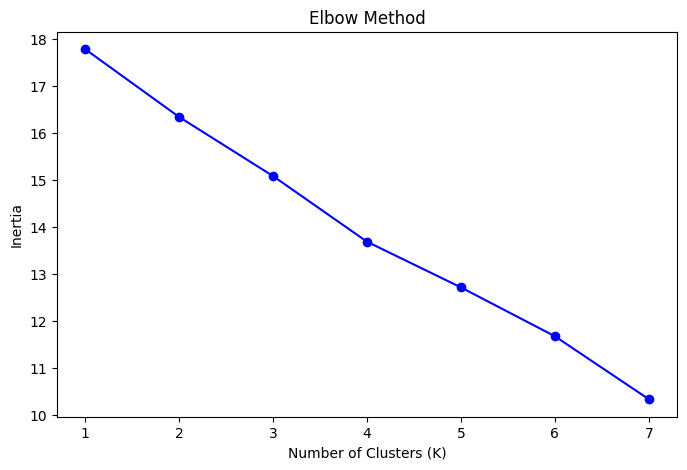

In [ ]:
k_values = range(1, 8)
inertias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(tfidf_matrix)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, 'bo-')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()


# SECTION 6: PCA Visualization

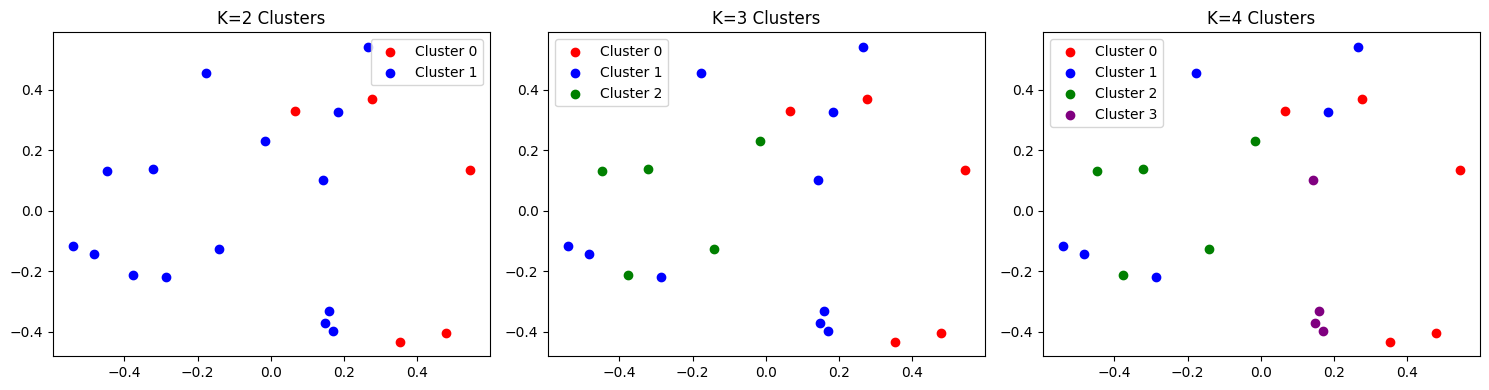

In [ ]:
pca = PCA(n_components=2)
tfidf_2d = pca.fit_transform(tfidf_matrix.toarray())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['red', 'blue', 'green', 'purple']

for i, k in enumerate([2, 3, 4]):
    ax = axes[i]
    labels = results[k]['labels']

    for cluster_id in range(k):
        cluster_points = tfidf_2d[labels == cluster_id]
        ax.scatter(cluster_points[:, 0], cluster_points[:, 1],
                  c=colors[cluster_id], label=f'Cluster {cluster_id}')

    ax.set_title(f'K={k} Clusters')
    ax.legend()

plt.tight_layout()
plt.show()

# SECTION 7: Two-Class Dataset Clustering

In [ ]:
# Load dataset with two classes
categories = ['alt.atheism', 'soc.religion.christian']
newsgroups = fetch_20newsgroups(subset='train', categories=categories,
                                shuffle=True, random_state=42)

# Use subset for faster processing
sample_texts = newsgroups.data[:100]
true_labels = newsgroups.target[:100]

print(f"\nTwo-class dataset: {len(sample_texts)} documents")
print(f"Categories: {newsgroups.target_names}")

# Vectorize and cluster
vectorizer_2class = TfidfVectorizer(stop_words='english', max_features=1000)
tfidf_2class = vectorizer_2class.fit_transform(sample_texts)

kmeans_2class = KMeans(n_clusters=2, random_state=42)
predicted_labels = kmeans_2class.fit_predict(tfidf_2class)

print(f"Silhouette Score: {silhouette_score(tfidf_2class, predicted_labels):.3f}")

# Show cluster distribution
for cluster_id in range(2):
    cluster_size = sum(predicted_labels == cluster_id)
    print(f"Cluster {cluster_id}: {cluster_size} documents")


Two-class dataset: 100 documents
Categories: ['alt.atheism', 'soc.religion.christian']
Silhouette Score: 0.008
Cluster 0: 37 documents
Cluster 1: 63 documents


# SECTION 8: Results Summary

In [ ]:
print("\n=== RESULTS SUMMARY ===")
print("\nTask 1 - 20 Documents:")
for k in [2, 3, 4]:
    labels = results[k]['labels']
    silhouette = silhouette_score(tfidf_matrix, labels)
    inertia = results[k]['model'].inertia_
    print(f"K={k}: Silhouette={silhouette:.3f}, Inertia={inertia:.3f}")

print(f"\nTask 2 - Two-class dataset:")
print(f"Silhouette Score: {silhouette_score(tfidf_2class, predicted_labels):.3f}")
print(f"Successfully clustered into 2 clusters")
print("\n=== RESULTS SUMMARY ===")
print("\nTask 1 - 20 Documents:")
for k in [2, 3, 4]:
    labels = results[k]['labels']
    silhouette = silhouette_score(tfidf_matrix, labels)
    inertia = results[k]['model'].inertia_
    print(f"K={k}: Silhouette={silhouette:.3f}, Inertia={inertia:.3f}")

print(f"\nTask 2 - Two-class dataset:")
print(f"Silhouette Score: {silhouette_score(tfidf_2class, predicted_labels):.3f}")
print(f"Successfully clustered into 2 clusters")

print("\nExperiment completed!")
print("\nExperiment completed!")


=== RESULTS SUMMARY ===

Task 1 - 20 Documents:
K=2: Silhouette=0.028, Inertia=16.346
K=3: Silhouette=0.027, Inertia=15.085
K=4: Silhouette=0.033, Inertia=13.687

Task 2 - Two-class dataset:
Silhouette Score: 0.008
Successfully clustered into 2 clusters

Experiment completed!
